In [1]:

# Deneyi farklı kategoriler için tekrarlamak istediğimizde sadece burayı değiştireceğiz.
CATEGORY =  "bottle"         # categories = "carpet" , "hazelnut" , "bottle"
# -----------------
print(f"Selected Category:{CATEGORY}")

Selected Category:bottle


In [2]:

import torch
import torchvision.models as models
from torchvision import transforms
import numpy as np
import time


model = models.wide_resnet50_2(weights=models.Wide_ResNet50_2_Weights.DEFAULT)

model.eval()

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

feature_layers = ['layer2', 'layer3']

print(f"\nModel hazır ve '{device}' cihazına taşındı.")

Downloading: "https://download.pytorch.org/models/wide_resnet50_2-9ba9bcbe.pth" to /root/.cache/torch/hub/checkpoints/wide_resnet50_2-9ba9bcbe.pth
100%|██████████| 263M/263M [00:01<00:00, 179MB/s]



Model hazır ve 'cuda' cihazına taşındı.
Özelliklerin alınacağı katmanlar: ['layer2', 'layer3']


In [3]:


features = {}

def get_features_hook(name):
    def hook(model, input, output):
        features[name] = output.detach()
    return hook

model.layer2.register_forward_hook(get_features_hook('layer2'))
model.layer3.register_forward_hook(get_features_hook('layer3'))



In [4]:
from google.colab import drive
import os
from PIL import Image
import glob
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

try:
    drive.mount('/content/drive', force_remount=True)
except Exception as e:
    drive.mount('/content/drive')
BASE_DIR = '/content/drive/MyDrive/LFD_Project/dataset/'
print("Drive bağlandı ve yollar tanımlandı.")

class MVTecDataset(Dataset):
    def __init__(self, root_dir, category, split='train'):
        self.root_dir = root_dir
        self.category = category
        self.split = split
        self.image_paths = []
        self.labels = []

        self.transform = transforms.Compose([
            transforms.Resize((256, 256), interpolation=transforms.InterpolationMode.BICUBIC),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])
        self._setup_paths()

    def _setup_paths(self):

        if self.split == 'train':
            class_dir = os.path.join(self.root_dir, self.category, 'train', 'good')
            self.image_paths = sorted(glob.glob(os.path.join(class_dir, '*.png')))
            self.labels = [0] * len(self.image_paths) # 0: Normal
        else: # test
            test_dir = os.path.join(self.root_dir, self.category, 'test')
            class_dirs = sorted([f for f in glob.glob(os.path.join(test_dir, '*')) if os.path.isdir(f)])
            for class_dir in class_dirs:
                class_name = os.path.basename(class_dir)
                paths = sorted(glob.glob(os.path.join(class_dir, '*.png')))
                self.image_paths.extend(paths)
                self.labels.extend([0 if class_name == 'good' else 1] * len(paths)) # 0: Normal, 1: Anomali

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        label = self.labels[idx]
        image = Image.open(image_path).convert("RGB")
        image_tensor = self.transform(image)

        return {"image": image_tensor, "label": label}


train_dataset = MVTecDataset(root_dir=BASE_DIR, category=CATEGORY, split="train")

train_dataloader = DataLoader(train_dataset, batch_size=8, shuffle=False, num_workers=2)

test_dataset = MVTecDataset(root_dir=BASE_DIR, category=CATEGORY, split="test")
test_dataloader = DataLoader(test_dataset, batch_size=8, shuffle=False, num_workers=2)

print(f"Eğitim için {len(train_dataset)}, test için {len(test_dataset)} görsel bulundu.")

Mounted at /content/drive
Drive bağlandı ve yollar tanımlandı.

Veri yükleyiciler oluşturuluyor...
Eğitim için 209, test için 83 görsel bulundu.
Veri yükleyiciler modele gönderilmeye hazır.


In [5]:

start_time = time.time()
print("\nTimer started. All subsequent computation time will be measured.")


Timer started. All subsequent computation time will be measured.


In [6]:
from tqdm import tqdm
import torch.nn.functional as F


memory_bank = []

with torch.no_grad():
    for batch in tqdm(train_dataloader, desc=f"'{CATEGORY}' için özellikler çıkarılıyor"):

        images = batch["image"].to(device)

        model(images)

        layer2_features = features['layer2']
        layer3_features = features['layer3']

        layer2_features_resized = F.interpolate(
            layer2_features,
            size=layer3_features.shape[2:],
            mode='bilinear',
            align_corners=False
        )

        combined_features = torch.cat((layer2_features_resized, layer3_features), dim=1)
        patch_features = combined_features.permute(0, 2, 3, 1).reshape(-1, combined_features.shape[1])

        memory_bank.append(patch_features)

memory_bank_tensor = torch.cat(memory_bank, dim=0)
memory_bank_tensor = memory_bank_tensor.cpu()

print(f"Toplam {memory_bank_tensor.shape[0]} adet yama (patch) özelliği hafızaya alındı")
print(f"Her bir yama {memory_bank_tensor.shape[1]} boyutta bir özellik vektörüne sahip")

'bottle' için özellikler çıkarılıyor: 100%|██████████| 27/27 [00:09<00:00,  2.76it/s]



İşlem tamamlandı
Hafıza bankası başarıyla oluşturuldu
Toplam 53504 adet yama (patch) özelliği hafızaya alındı
Her bir yama 1536 boyutta bir özellik vektörüne sahip


In [7]:
import torch
import random


coreset_percentage = 0.10
coreset_size = int(len(memory_bank_tensor) * coreset_percentage)

indices = torch.tensor(random.sample(range(len(memory_bank_tensor)), coreset_size))

coreset = memory_bank_tensor[indices]

print(f"Hafıza bankasındaki {len(memory_bank_tensor)} adet yamadan, %{coreset_percentage*100} oranında rastgele örnekleme yapıldı.")
print(f"Yeni 'coreset' (özet hafıza bankası) boyutu: {coreset.shape}")

Hafıza bankasındaki 53504 adet yamadan, %10.0 oranında rastgele örnekleme yapıldı.
Yeni 'coreset' (özet hafıza bankası) boyutu: torch.Size([5350, 1536])


In [8]:


test_dataset = MVTecDataset(root_dir=BASE_DIR, category=CATEGORY, split='test')

test_dataloader = DataLoader(
    dataset=test_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2
)

print(f"Test veri yükleyici oluşturuldu. İçerdiği görsel sayısı: {len(test_dataset)}")

Test veri yükleyici oluşturuldu. İçerdiği görsel sayısı: 83


In [9]:
from sklearn.neighbors import NearestNeighbors


nn_search_engine = NearestNeighbors(n_neighbors=1, algorithm='ball_tree', p=2)

print("Arama motoru, coreset verisiyle yapılandırılıyor")
nn_search_engine.fit(coreset)

print("\nEn Yakın Komşu Arama Motoru başarıyla kuruldu.")

Arama motoru, coreset verisiyle yapılandırılıyor

En Yakın Komşu Arama Motoru başarıyla kuruldu.


In [10]:
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch.nn.functional as F
import torch
import numpy as np



test_image_scores = []
test_labels = []

with torch.no_grad():
    for batch in tqdm(test_dataloader, desc=f"Testing on '{CATEGORY}'"):
        images = batch["image"].to(device)
        labels = batch["label"]

        model(images)

        layer2_features = features['layer2']
        layer3_features = features['layer3']
        layer2_features_resized = F.interpolate(layer2_features, size=layer3_features.shape[2:], mode='bilinear', align_corners=False)
        combined_features = torch.cat((layer2_features_resized, layer3_features), dim=1)
        patch_features = combined_features.permute(0, 2, 3, 1).reshape(-1, combined_features.shape[1])
        patch_features_cpu = patch_features.cpu()

        patch_scores, _ = nn_search_engine.kneighbors(patch_features_cpu)

        patches_per_image = layer3_features.shape[2] * layer3_features.shape[3]
        image_scores = patch_scores.reshape(len(images), patches_per_image)

        max_image_scores = torch.tensor(np.max(image_scores, axis=1))

        test_image_scores.append(max_image_scores)
        test_labels.append(labels)

all_scores = torch.cat(test_image_scores).numpy()
all_labels = torch.cat(test_labels).numpy()

auroc_score = roc_auc_score(all_labels, all_scores)

print(f"Calculated AUROC Score for Manual PatchCore ({CATEGORY.capitalize()}): {auroc_score:.4f}")

Testing on 'bottle': 100%|██████████| 11/11 [04:18<00:00, 23.54s/it]

Calculated AUROC Score for Manual PatchCore (Bottle): 0.9937


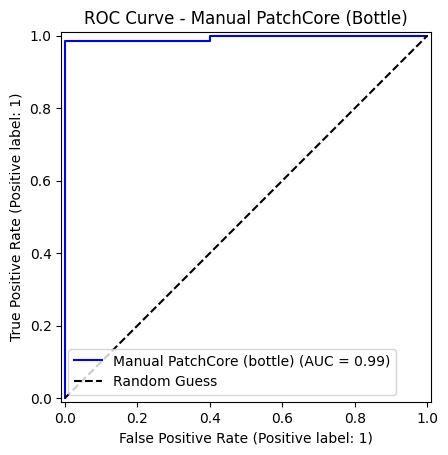

In [11]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt


RocCurveDisplay.from_predictions(
    all_labels,
    all_scores,
    name=f"Manual PatchCore ({CATEGORY})",
    color="blue"
)

plt.plot([0, 1], [0, 1], "k--", label="Random Guess")
plt.title(f"ROC Curve - Manual PatchCore ({CATEGORY.capitalize()})")
plt.legend()
plt.show()

Best Threshold found based on ROC curve: 28.7660
Model performance at this threshold:
              precision    recall  f1-score   support

      Normal       0.95      1.00      0.98        20
     Anomaly       1.00      0.98      0.99        63

    accuracy                           0.99        83
   macro avg       0.98      0.99      0.98        83
weighted avg       0.99      0.99      0.99        83


--- Confusion Matrix ---


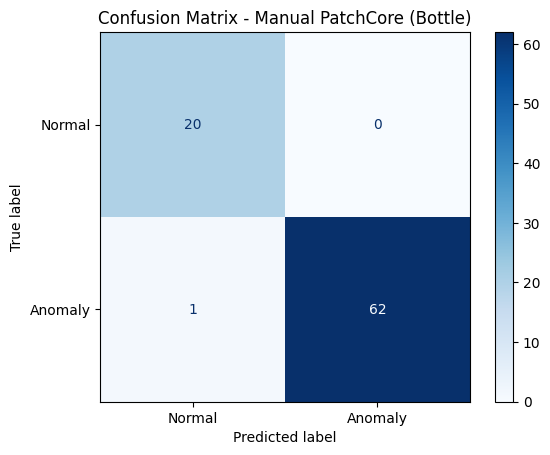

In [12]:
from sklearn.metrics import roc_curve, ConfusionMatrixDisplay, classification_report
import numpy as np
import matplotlib.pyplot as plt


fpr, tpr, thresholds = roc_curve(all_labels, all_scores)

J = tpr - fpr
ix = np.argmax(J)
best_thresh = thresholds[ix]
print(f"Best Threshold found based on ROC curve: {best_thresh:.4f}")
print("Model performance at this threshold:")

y_pred = (all_scores >= best_thresh).astype(int)

display_labels_report = ['Normal', 'Anomaly']
print(classification_report(all_labels, y_pred, target_names=display_labels_report))

print("\n--- Confusion Matrix ---")
display_labels_cm = ['Normal', 'Anomaly']
ConfusionMatrixDisplay.from_predictions(all_labels, y_pred, display_labels=display_labels_cm, cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix - Manual PatchCore ({CATEGORY.capitalize()})")
plt.show()

In [13]:

end_time = time.time()
elapsed_time = end_time - start_time

print(f"The process took {elapsed_time:.2f} seconds.")
print(f"({elapsed_time / 60:.2f} minutes)")

The process took 271.51 seconds.
(4.53 minutes)
